In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
try:
    QDRANT_URL = os.environ["QDRANT_URL"]
    print("QDRANT_URL loaded successfully")
except KeyError:
    raise ValueError("QDRANT_URL is not set — check your .env file")

QDRANT_URL loaded successfully


In [3]:
import sys
print(sys.executable)

/home/onyxia/work/funathon-project2/.venv/bin/python3


Conectamos con la api de ia generativa

In [4]:
from openai import OpenAI

client_llmlab = OpenAI(
    base_url=os.environ["LLMLAB_URL"],
    api_key=os.environ["LLMLAB_API_KEY"],
)

# Print models list
models = client_llmlab.models.list()
for model in models.data:
    print(f"ID: {model.id}")

ID: gemma4-26b-moe
ID: qwen3-6-35b-moe
ID: qwen3-embedding-8b


Conectamos con la bd vectorial

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()
#no actualiza cambios de otra forma
load_dotenv(override=True)

print("QDRANT_URL:", os.environ["QDRANT_URL"])
print("QDRANT_API_PORT:", os.environ["QDRANT_API_PORT"])

QDRANT_URL: https://user-teresafernandez-qdrant.user.lab.sspcloud.fr/
QDRANT_API_PORT: 443


In [6]:
from qdrant_client import QdrantClient

client_qdrant = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
    port=os.environ["QDRANT_API_PORT"],
    check_compatibility=False
)



In [7]:

collections = client_qdrant.get_collections()
for collection in collections.collections:
    print(collection.name)

nace-collection


In [7]:
import duckdb
con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

path_nace = 'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/NACE_Rev2.1_Structure_Explanatory_Notes_EN.tsv'
query_definition = f"SELECT * FROM read_csv('{path_nace}')"
table = con.execute(query_definition).to_arrow_table()
nace = table.to_pylist()

nace[22]

{'ORDER_KEY': 230,
 'ID': '014',
 'CODE': '01.4',
 'HEADING': 'Animal production',
 'PARENT_ID': '01',
 'PARENT_CODE': '01',
 'LEVEL': 3,
 'Implementation_rule': None,
 'Includes': 'This group includes:\\n- farming (husbandry, raising) and breeding of all animals, except aquatic animals',
 'IncludesAlso': None,
 'Excludes': 'This group excludes:\\n- farm animal boarding and care, see 01.62\\n- production of hides and skins from slaughterhouses, see 10.11'}

Build a class NaceDocument that will help you handle your NACE documents :

- Cleans features (‘HEADING’, ‘Includes’, etc.) with a _clean method;
- Checks your data (example: hierarchical coherence);
- Creates a structured text for each code:
     - example: attribute text, created by a to_embedding_text method;
     - this text will be ready to be embedded;
     - It would be best to parametrize whether to include or not each possible field (e.g : text with or without “Excludes” feature).

In [10]:
from dataclasses import dataclass, field
from typing import Optional

def _clean(value) -> Optional[str]:
    """Normalize to stripped single-line string, or None if empty/missing."""
    if value is None:
        return None
    # str() handles non-string values (int, float...) from raw dicts
    # replace("\n", " ") flattens multiline strings to a single line
    # split() tokenizes on any whitespace, join(" ") rebuilds with single spaces
    cleaned = " ".join(str(value).replace("\n", " ").split())
    # Empty string is falsy in Python — return None instead for consistency
    return cleaned or None

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)

    @classmethod
    def from_raw(cls, raw: dict, with_includes_also=True, with_excludes=False,) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

nace_documents = []
for nace_code in nace:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

In [11]:
from pprint import pprint

i = 50
print(f"Printing index {i}:")

print("=============================================")
print("=============================================")

nace_example = nace[i]
doc_example = NaceDocument.from_raw(nace_example)

print("\nPrinting text to embed (WITH exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=True,
)
print(doc_example.text)

print("=============================================")
print("=============================================")

print("\nPrinting text to embed (WITHOUT exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=False,
)
print(doc_example.text)

Printing index 50:

Printing text to embed (WITH exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)

Printing text to embed (WITHOUT exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)


In [8]:
EMB_MODEL_NAME = "qwen3-embedding-8b"
emb_dim = 4096

In [13]:
from qdrant_client.models import Distance, VectorParams

COLLECTION_NAME = "nace-collection"

# Delete the collection if necessary
if client_qdrant.collection_exists(collection_name=COLLECTION_NAME):
    client_qdrant.delete_collection(collection_name=COLLECTION_NAME)

# Create the collection
client_qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=emb_dim,
        distance=Distance.COSINE
    )
)

True

In [14]:
from dataclasses import dataclass, field
from typing import Optional, List


@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

In [17]:
# Recreate your NACE documents (that class has been updated)

sample_size = 10

nace_documents = []
for nace_code in nace[:sample_size]:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

for nace_doc in nace_documents:
    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

In [18]:
print("\nPrinting the first document:")
print(nace_documents[0])

print("\nPrinting the embedding vector of the first document:")
print(nace_documents[0].vector)

print(f"\nLength of this vector: {len(nace_documents[0].vector)}")


Printing the first document:
NaceDocument(code='A', heading='AGRICULTURE, FORESTRY AND FISHING', level=1, parent_code=None, includes='This section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.', includes_also='This section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.', excludes='This section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10.', text='# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and th

# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)

## Excludes
This class excludes:
- frog farming, see 03.22\n
- operation of sport fishing preserves, see 93.19

In [30]:
from dataclasses import dataclass, field
from typing import Optional, List
from uuid import uuid5, NAMESPACE_DNS
from qdrant_client.models import PointStruct

NACE_NAMESPACE = uuid5(NAMESPACE_DNS, "nace-rev2")

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

    def to_qdrant_point(
        self,
    ) -> PointStruct:

        if not hasattr(self, "vector") or self.vector is None:
            raise ValueError("vector is missing or Null")
        return PointStruct(
            # uuid5 is deterministic: same namespace + code always yields the same UUID
            # stable across runs, valid for Qdrant, no hacky string manipulation needed
            id=str(uuid5(NACE_NAMESPACE, self.code)),
            vector=self.vector,
            payload={
                "code": self.code,
                "level": self.level,
                "parent_code": self.parent_code,
                # Storing the text used for embedding enables inspection and debugging
                "text": self.text,
            }
        )

In [20]:
nace_points = []

for nace_code in nace:
    nace_doc = NaceDocument.from_raw(
        raw=nace_code,
        with_includes_also=True,
        with_excludes=True
    )

    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

    nace_points.append(
        nace_doc.to_qdrant_point()
    )

In [21]:
import json

point = nace_points[0]
point_dict = point.model_dump()

# Truncate the vector for readability (full vector is hundreds of floats)
vector = point_dict["vector"]
point_dict["vector"] = f"[{vector[0]:.4f}, {vector[1]:.4f}, ..., {vector[-1]:.4f}]  ({len(vector)} dims)"

print("Check the first PointStruct:\n")
print(json.dumps(point_dict, indent=2, ensure_ascii=False))

Check the first PointStruct:

{
  "id": "bf20fdf8-5b6a-5d28-b1f6-7a472c5564ac",
  "vector": "[0.0139, 0.0089, ..., -0.0044]  (4096 dims)",
  "payload": {
    "code": "A",
    "level": 1,
    "parent_code": null,
    "text": "# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.\n\n## Also includes:\nThis section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.\n\n## Excludes:\nThis section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10."
  }
}


In [22]:
from more_itertools import chunked
from tqdm import tqdm

BATCH_SIZE = 16
batches = list(chunked(nace_points, BATCH_SIZE))

for batch in tqdm(batches, desc="Uploading to Qdrant", unit="batch"):
    try:
        client_qdrant.upsert(
            collection_name=COLLECTION_NAME,
            points=batch,
        )
    except Exception as e:
        tqdm.write(f"✗ Batch failed: {e}")

Uploading to Qdrant: 100%|██████████| 66/66 [00:06<00:00, 10.36batch/s]


In [23]:
count = client_qdrant.count(collection_name=COLLECTION_NAME)
print(count)

count=1047


RAG pipeline approach - Query a LLM for automatic coding

In [25]:
# Models
EMB_MODEL_NAME = "qwen3-embedding-8b"   # Embedding model
GEN_MODEL_NAME = "gemma4-26b-moe"          # Generative model

# Qdrant
COLLECTION_NAME = "nace-collection"
RETRIEVER_LIMIT = 5    # Number of candidates returned by the vector search

# Generation
TEMPERATURE = 0.1      # Low temperature → more deterministic, reproducible outputs

# Evaluation
SAMPLE_SIZE = 500       # Number of activities to evaluate (increase for more robust results)

In [26]:
activity = "Installation, maintenance and repair of residential air conditioning systems for private customers"

In [27]:
response = client_llmlab.embeddings.create(
    model=EMB_MODEL_NAME,
    input=activity
)

search_embedding = response.data[0].embedding

print(f"Vector created of length: {len(search_embedding)}")

Vector created of length: 4096


Question 2 — Retrieval: search for NACE candidates

In [28]:
points = client_qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=search_embedding,
    limit=RETRIEVER_LIMIT,
)

descriptions_retrieved = []
codes_retrieved = []

for point in points.model_dump()["points"]:
    descriptions_retrieved.append(point["payload"]["text"])
    codes_retrieved.append(point["payload"]["code"])

print(
    f"✓ Vector search completed: {len(descriptions_retrieved)} codes and descriptions retrieved\n"
)
print("Check the first code retrieved ==============\n")
print(descriptions_retrieved[0])

✓ Vector search completed: 5 codes and descriptions retrieved

Check the first code retrieved ==============

# Code: 35.3
# Title: Steam and air conditioning supply


Prompt construction
- The system prompt: defines the model’s general role and behaviour.
- The user prompt: contains request-specific information (label to code, candidates, output format instructions).

_Constraining the output to JSON format is a best practice: it simplifies automatic parsing and reduces format hallucinations._

In [29]:
SYSTEM_PROMPT = """\
You are an expert classifier for the NACE 2.1 nomenclature (Statistical Classification of Economic Activities in the European Community).

Given a company activity description and a short list of candidate NACE codes, your job is to pick the single most appropriate code from the candidates — or to declare the activity not codable if the description is too ambiguous.

Always reply with a valid JSON object matching the requested schema. No explanations, no extra text.
"""

USER_PROMPT_TEMPLATE = """\
## Activity to classify
{activity}

## Candidate NACE codes and their explanatory notes
{proposed_nace_descriptions}

## Rules
- Pick exactly one code from this list: [{proposed_nace_codes}]. Do not invent codes outside the list.
- If several activities are mentioned, only consider the first one.
- If the description is too vague to decide, return `nace_code: null` and `codable: false`.

## Output — valid JSON only
{{
  "nace_code": "<one code from the candidate list, or null>",
  "codable": <true | false>,
  "confidence": <float between 0.0 and 1.0>
}}
"""

Question 3 — LLM inference

In [30]:
from pydantic import BaseModel, Field
from typing import Optional

class NaceClassificationResult(BaseModel):
    nace_code: Optional[str] = Field(description="Chosen NACE code from the candidate list, or null")
    codable: bool = Field(description="False if the description is too vague to code")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence score between 0 and 1")

In [31]:
import json

user_prompt = USER_PROMPT_TEMPLATE.format(
    activity=activity,
    proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
    proposed_nace_codes=", ".join(codes_retrieved)
)

response = client_llmlab.chat.completions.parse(
    model=GEN_MODEL_NAME,
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt}
    ],
    temperature=TEMPERATURE,
    response_format=NaceClassificationResult,
)

llm_response: NaceClassificationResult = response.choices[0].message.parsed
print(json.dumps(llm_response.model_dump(), indent=2))

{
  "nace_code": "43.2",
  "codable": true,
  "confidence": 0.9
}


## Inference on multiple activities

Next, let’s use some synthetic data. We will:

run automatic classification on a sample of labelled activities,
build metrics to evaluate the quality of the coding process.


### Load the data

In [32]:
import duckdb

con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

query_definition = f"""
SELECT *
FROM read_parquet(
  'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet'
)
USING SAMPLE {SAMPLE_SIZE}
"""

annotations = (
    con.sql(query_definition)
    .to_df()
    .to_dict(orient="records")
)
print(f"Dataset loaded: {len(annotations)} rows")
print(f"Keys: {list(annotations[0].keys())}")
annotations[:2]

Dataset loaded: 500 rows
Keys: ['code', 'name', 'label']


[{'code': '70.20',
  'name': 'Business and other management consultancy activities',
  'label': 'New venture formation guidance'},
 {'code': '96.22',
  'name': 'Beauty care and other beauty treatment activities',
  'label': 'Facial aesthetics and rejuvenation therapy'}]

### Utility function: a full pipeline call

Before looping, we encapsulate steps 1–4 into a reusable function.

In [33]:
def run_rag_pipeline(activity: str) -> dict:
    """
    Run the full RAG pipeline for a single activity label.

    Parameters
    ----------
    activity : str
        Free-text economic activity label to be coded.

    Returns
    -------
    dict with keys:
        - nace_code (str | None) : predicted NACE code
        - codable (bool)        : True if the label could be coded
        - confidence (float)    : confidence score (0–1)
        - retrieved_codes (list): candidates returned by the retriever
    """
    # --- Step 1: Embedding ---
    emb_response = client_llmlab.embeddings.create(model=EMB_MODEL_NAME, input=activity)
    embedding = emb_response.data[0].embedding

    # --- Step 2: Retrieval ---
    points = client_qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=embedding,
        limit=RETRIEVER_LIMIT,
    )
    descriptions_retrieved = []
    codes_retrieved = []
    for point in points.model_dump()["points"]:
        descriptions_retrieved.append(point["payload"]["text"])
        codes_retrieved.append(point["payload"]["code"])

    # --- Step 3: Prompt construction ---
    user_prompt = USER_PROMPT_TEMPLATE.format(
        activity=activity,
        proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
        proposed_nace_codes=", ".join(codes_retrieved),
    )

    # --- Step 4: LLM inference ---
    gen_response = client_llmlab.chat.completions.parse(
        model=GEN_MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=TEMPERATURE,
        response_format=NaceClassificationResult,
    )

    result = gen_response.choices[0].message.parsed.model_dump()
    # Keep retrieved candidates for retriever evaluation
    result["retrieved_codes"] = codes_retrieved

    return result

### Inference loop

Exercise 2: Code all activities in the dataset
Apply run_rag_pipeline to every row of the annotations list. Store the results in a DataFrame called results.   

_NOTE: The default sample size is SAMPLE_SIZE = 100, which keeps inference fast and avoids consuming too many resources. Each call to the pipeline involves two API requests (embedding + generation), so larger samples will take proportionally longer. Feel free to increase SAMPLE_SIZE in the global parameters to get more robust evaluation metrics._


In [34]:
from tqdm import tqdm
import pandas as pd

records = []

for row in tqdm(annotations, total=len(annotations), desc="Coding"):
    activity_label = row["label"]
    true_code      = row["code"]

    try:
        pred = run_rag_pipeline(activity_label)
    except Exception as e:
        pred = {
            "nace_code":       None,
            "codable":        False,
            "confidence":     0.0,
            "retrieved_codes": []
        }
        print(f"⚠ Error for '{activity_label[:60]}...': {e}")

    records.append({
        "activity":        activity_label,
        "true_code":       true_code,
        "pred_code":       pred.get("nace_code"),
        "codable":         pred.get("codable", False),
        "confidence":      pred.get("confidence", 0.0),
        "retrieved_codes": pred.get("retrieved_codes", []),
    })

results = pd.DataFrame(records)
print(f"\n✓ Inference complete: {len(results)} activities processed")
results.head()

Coding: 100%|██████████| 500/500 [25:53<00:00,  3.11s/it]


✓ Inference complete: 500 activities processed


,activity,true_code,pred_code,codable,confidence,retrieved_codes
0,New venture formation guidance,70.20,70.2,True,0.95,"[70.2, 85.6, 68, 82.4, 81.1]"
1,Facial aesthetics and rejuvenation therapy,96.22,None,False,0.50,"[96.2, 96.22, 74.2, 86.22, 86.99]"
2,Specialized business solutions provision,70.20,None,False,0.00,"[70.2, 62.9, 82.4, 43.6, 62.2]"
3,Personal appearance care provision,96.22,96.2,True,0.90,"[96.2, 96, 96.9, 96.22, 47.75]"
4,Long-term real estate asset utilization,68.20,68.2,True,0.90,"[68, 68.2, 68.3, 77.5, 77.3]"


### Prepare evaluation columns

Before computing any metric, add three boolean columns to results:

- retriever_hit: whether the true NACE code is among the k candidates returned by Qdrant
- pipeline_correct: whether the predicted code matches the true code
- llm_correct_given_retriever: same as pipeline_correct, but set to None when the retriever did not return the true code

In [35]:
# Is the true code among the retriever's candidates?
results["retriever_hit"] = results.apply(
    lambda row: row["true_code"] in row["retrieved_codes"], axis=1
)

# Is the predicted code correct?
results["pipeline_correct"] = results["pred_code"] == results["true_code"]

# Did the LLM pick the right code, given that the retriever found it?
results["llm_correct_given_retriever"] = results.apply(
    lambda row: row["pipeline_correct"] if row["retriever_hit"] else None,
    axis=1
)

In [36]:
results.head()

,activity,true_code,pred_code,codable,confidence,retrieved_codes,retriever_hit,pipeline_correct,llm_correct_given_retriever
0,New venture formation guidance,70.20,70.2,True,0.95,"[70.2, 85.6, 68, 82.4, 81.1]",False,False,None
1,Facial aesthetics and rejuvenation therapy,96.22,None,False,0.50,"[96.2, 96.22, 74.2, 86.22, 86.99]",True,False,False
2,Specialized business solutions provision,70.20,None,False,0.00,"[70.2, 62.9, 82.4, 43.6, 62.2]",False,False,None
3,Personal appearance care provision,96.22,96.2,True,0.90,"[96.2, 96, 96.9, 96.22, 47.75]",True,False,False
4,Long-term real estate asset utilization,68.20,68.2,True,0.90,"[68, 68.2, 68.3, 77.5, 77.3]",False,False,None


#### Question 1 — Retriever accuracy (Retriever@k)

Retriever@k accuracy measures the proportion of cases where the reference code is present among the k candidates returned by Qdrant. It is the theoretical ceiling of the pipeline: if the retriever misses the correct code, the LLM cannot recover it.

In [37]:
retriever_accuracy = results["retriever_hit"].mean()
print(f"Retriever@{RETRIEVER_LIMIT} accuracy: {retriever_accuracy:.1%}")
print(f"  → {results['retriever_hit'].sum()} / {len(results)} correctly retrieved")

Retriever@5 accuracy: 54.8%
  → 274 / 500 correctly retrieved


#### Question 2 - Conditional LLM accuracy

Conditional LLM accuracy measures how often the LLM picks the right code when the retriever already returned it as a candidate. This metric isolates the LLM’s own contribution to the pipeline.

In [38]:
retriever_success = results[results["retriever_hit"]]
llm_accuracy = retriever_success["pipeline_correct"].mean()

print(f"LLM accuracy (conditional on retriever): {llm_accuracy:.1%}")
print(f"  → {retriever_success['pipeline_correct'].sum()} / {len(retriever_success)} correctly coded by the LLM")

LLM accuracy (conditional on retriever): 90.9%
  → 249 / 274 correctly coded by the LLM


#### Question 3 — End-to-end pipeline accuracy

End-to-end pipeline accuracy is the proportion of activity labels that are correctly coded, regardless of which component failed.

In [39]:
pipeline_accuracy = results["pipeline_correct"].mean()

print(f"Pipeline accuracy (end-to-end)          : {pipeline_accuracy:.1%}")
print(f"  → {results['pipeline_correct'].sum()} / {len(results)} correctly coded")
print()
print(f"Cross-check: Retriever@k × LLM = {retriever_accuracy:.3f} × {llm_accuracy:.3f} = {retriever_accuracy * llm_accuracy:.1%}")

Pipeline accuracy (end-to-end)          : 49.8%
  → 249 / 500 correctly coded

Cross-check: Retriever@k × LLM = 0.548 × 0.909 = 49.8%


#### Question 4 — Summary dashboard and error decomposition

Count how many errors come from the retriever (cases where retriever_hit is False) and how many come from the LLM (cases where retriever_hit is True but pipeline_correct is False). Then produce a summary table of all metrics.

How to interpret the error decomposition:

- If retriever errors dominate → improve the embedding model, increase k, or enrich NACE descriptions in the vector store.
- If LLM errors dominate → refine the prompt, switch to a more capable generative model, or lower the temperature further.

In [40]:
n_total          = len(results)
n_retriever_miss = (~results["retriever_hit"]).sum()
n_llm_miss       = (results["retriever_hit"] & ~results["pipeline_correct"]).sum()
n_correct        = results["pipeline_correct"].sum()

print(
    "\n".join(
        [
            "=" * 52,
            "      DASHBOARD — RAG PIPELINE NACE 2.1",
            "=" * 52,
            f"  Activities processed        : {n_total:>6}",
            f"  Correctly coded             : {n_correct:>6}  ({pipeline_accuracy:.1%})",
            "",
            f"  Retriever@{RETRIEVER_LIMIT} accuracy        : {retriever_accuracy:>6.1%}",
            f"  LLM accuracy (conditional)  : {llm_accuracy:>6.1%}",
            f"  Pipeline accuracy           : {pipeline_accuracy:>6.1%}",
            "",
            f"  Retriever errors            : {n_retriever_miss:>6}  ({n_retriever_miss / n_total:.1%})",
            f"  LLM errors                  : {n_llm_miss:>6}  ({n_llm_miss / n_total:.1%})",
            "=" * 52,
        ]
    )
)

      DASHBOARD — RAG PIPELINE NACE 2.1
  Activities processed        :    500
  Correctly coded             :    249  (49.8%)

  Retriever@5 accuracy        :  54.8%
  LLM accuracy (conditional)  :  90.9%
  Pipeline accuracy           :  49.8%

  Retriever errors            :    226  (45.2%)
  LLM errors                  :     25  (5.0%)


#### Question 5 — Confidence score analysis

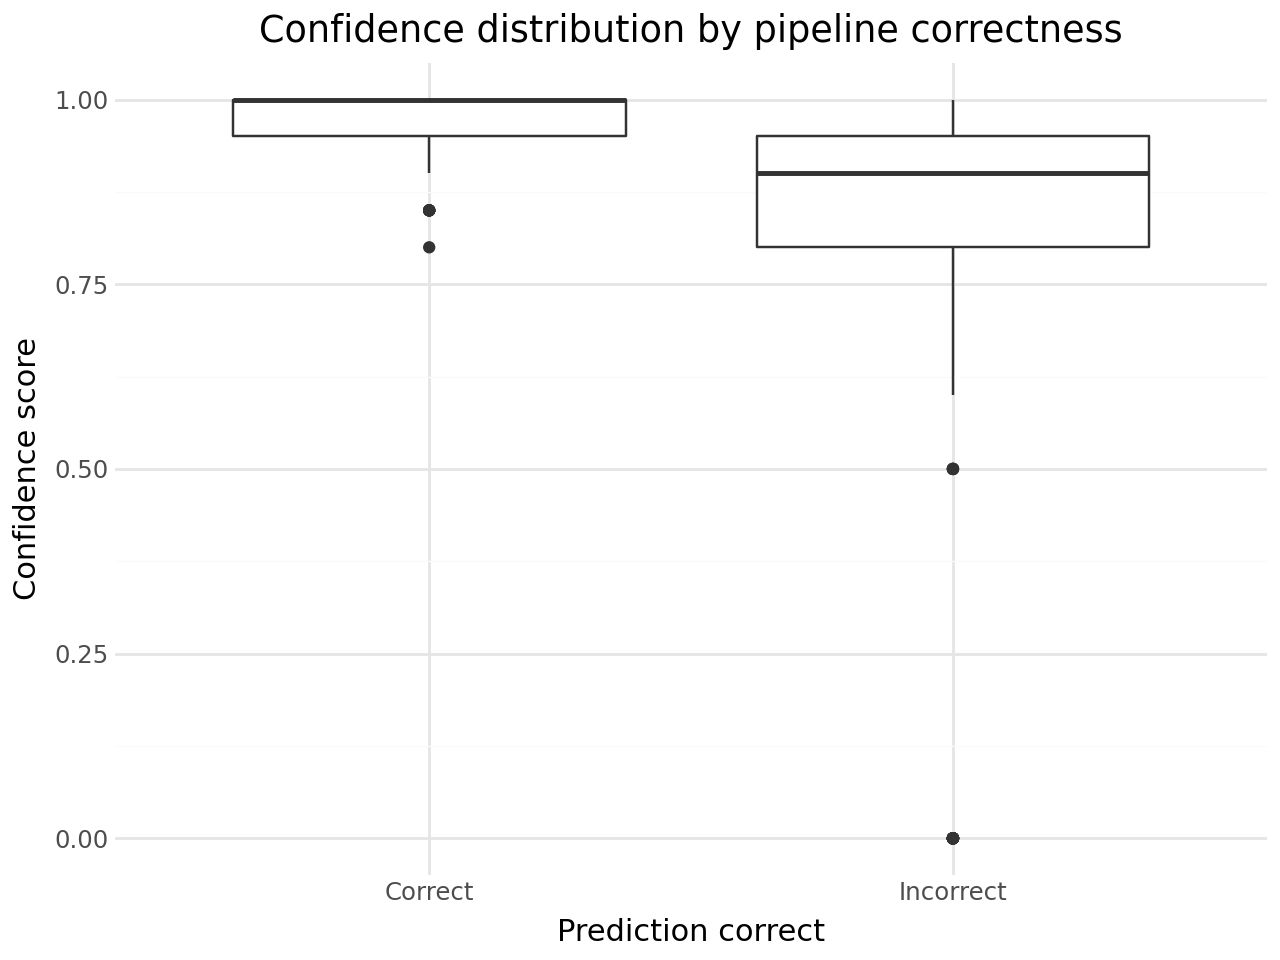

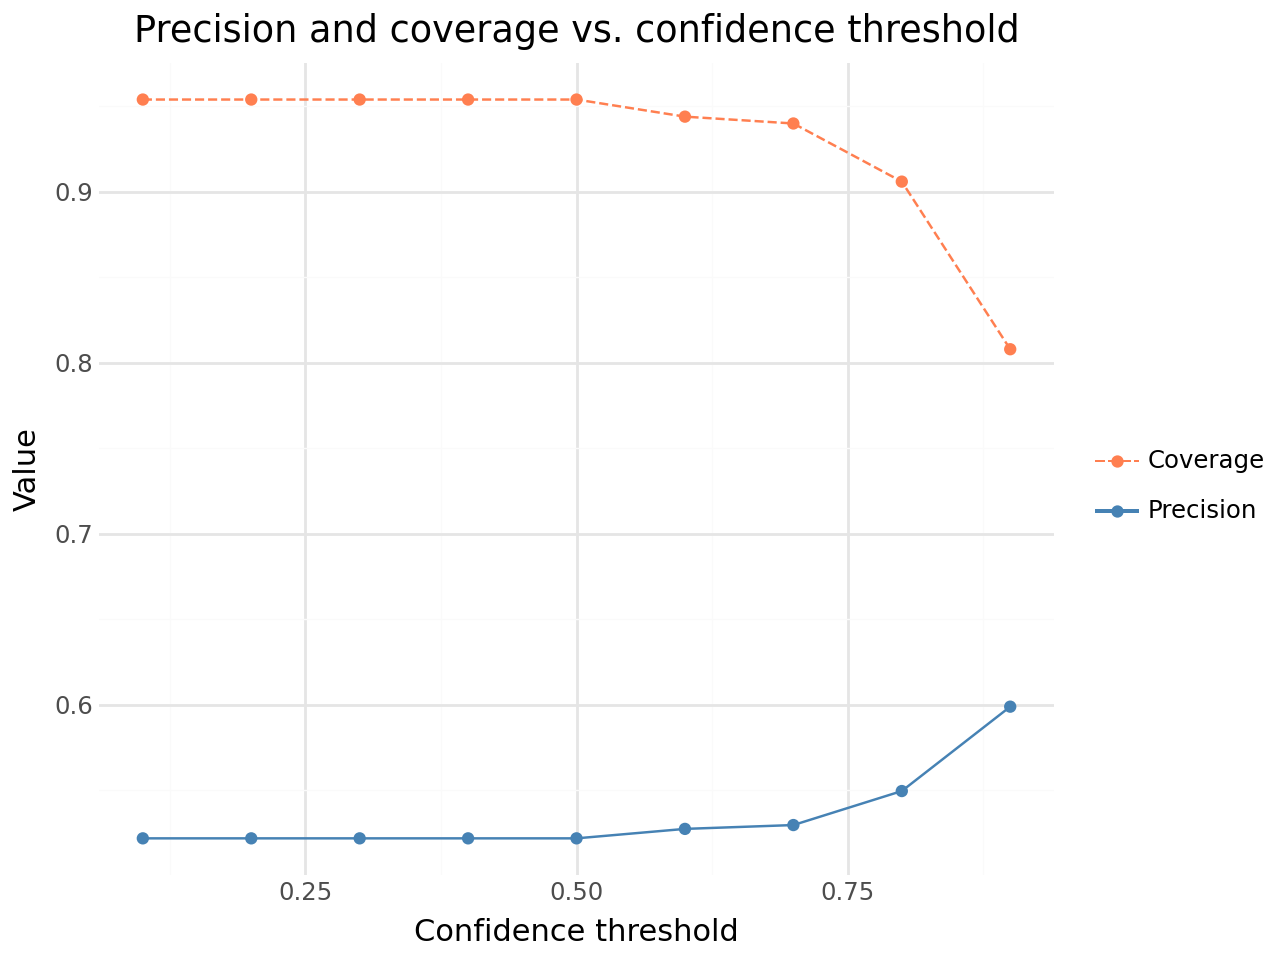

In [42]:
from plotnine import (
    ggplot, aes,
    geom_boxplot, geom_line, geom_point,
    scale_color_manual, scale_linetype_manual,
    labs, theme_minimal,
)


# --- Left: confidence distribution by correctness ---
results_plot = results.assign(
    correctness=results["pipeline_correct"].map({False: "Incorrect", True: "Correct"})
)

p1 = (
    ggplot(results_plot, aes(x="correctness", y="confidence"))
    + geom_boxplot()
    + labs(
        title="Confidence distribution by pipeline correctness",
        x="Prediction correct",
        y="Confidence score",
    )
    + theme_minimal()
)

# --- Right: precision and coverage vs confidence threshold ---
thresholds = [i / 10 for i in range(1, 10)]
rows = []
for t in thresholds:
    subset = results[results["confidence"] >= t]
    if len(subset) > 0:
        rows += [
            {"threshold": t, "metric": "Precision", "value": subset["pipeline_correct"].mean()},
            {"threshold": t, "metric": "Coverage",  "value": len(subset) / len(results)},
        ]

df_thresh = pd.DataFrame(rows)

p2 = (
    ggplot(df_thresh, aes(x="threshold", y="value", color="metric", linetype="metric"))
    + geom_line()
    + geom_point()
    + scale_color_manual(values={"Precision": "steelblue", "Coverage": "coral"})
    + scale_linetype_manual(values={"Precision": "solid", "Coverage": "dashed"})
    + labs(
        title="Precision and coverage vs. confidence threshold",
        x="Confidence threshold",
        y="Value",
        color="",
        linetype="",
    )
    + theme_minimal()
)

from IPython.display import display
display(p1)
display(p2)

In [44]:
import polars as pl
points_df = (
    pl.DataFrame(points.model_dump())
    .unnest()
    .unnest()
    .select(["id", "score", "code", "text"])
)

In [ ]:
def run_rag_pipeline(activity: str) -> dict:
    """
    Run the full RAG pipeline for a single activity label.

    Parameters
    ----------
    activity : str
        Free-text economic activity label to be coded.

    Returns
    -------
    dict with keys:
        - nace_code (str | None) : predicted NACE code
        - codable (bool)        : True if the label could be coded
        - confidence (float)    : confidence score (0–1)
        - retrieved_codes (list): candidates returned by the retriever
    """
    # --- Step 1: Embedding ---
    emb_response = client_llmlab.embeddings.create(model=EMB_MODEL_NAME, input=activity)
    embedding = emb_response.data[0].embedding

    # --- Step 2: Retrieval ---
    points = client_qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=embedding,
        limit=RETRIEVER_LIMIT,
    )

    points_df = (
        pl.DataFrame(points.model_dump(), schema_overrides={"points": pl.Struct})
        .unnest()
        .unnest()
        .select(["id", "score", "code", "text"])
    )

    # --- Step 3: Prompt construction ---
    user_prompt = USER_PROMPT_TEMPLATE.format(
        activity=activity,
        proposed_nace_descriptions="## " + "\n\n## ".join(points_df["text"]),
        proposed_nace_codes=", ".join(points_df["code"]),
    )

    # --- Step 4: LLM inference ---
    gen_response = client_llmlab.chat.completions.create(
        model=GEN_MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=TEMPERATURE,
        response_format={"type": "json_object"},
    )

    result = json.loads(gen_response.choices[0].message.content)
    # Keep retrieved candidates for retriever evaluation
    result["retrieved_codes"] = points_df["code"]

    return result


annotations_df = pl.DataFrame(annotations)

results_df = annotations_df.with_columns(
    pl.col("label")
    .map_elements(
        lambda a: run_rag_pipeline(a),
        return_dtype=pl.Struct(
            {
                "nace_code": pl.Utf8,
                "codable": pl.Boolean,
                "confidence": pl.Float64,
                "retrieved_codes": pl.List(pl.Utf8),
            }
        ),
    )
    .alias("pred")
).unnest()

# Metrics
results_df = (
    results_df.with_columns(
        retriever_hit=pl.col("code").is_in(pl.col("retrieved_codes")),
        pipeline_correct=pl.col("code") == pl.col("nace_code"),
    )
    .with_columns(
        pipeline_correct=pl.col("pipeline_correct").fill_null(
            False  # if no prediction - pipeline is false
        )
    )
    .with_columns(
        llm_correct_given_retriever=pl.when(pl.col("retriever_hit"))
        .then(pl.col("pipeline_correct"))
        .otherwise(None),
    )
)

# Q1
results_df["retriever_hit"].value_counts()
retriever_accuracy = results_df["retriever_hit"].mean()

# Q2
results_df["llm_correct_given_retriever"].value_counts()
results_df.filter(pl.col("retriever_hit"))["llm_correct_given_retriever"].value_counts()
llm_accuracy = results_df.filter(pl.col("retriever_hit"))[
    "llm_correct_given_retriever"
].mean()

# Q3
results_df["pipeline_correct"].value_counts()
pipeline_accuracy = results_df["pipeline_correct"].mean()
pipeline_accuracy
llm_accuracy * retriever_accuracy

# Q4
n_total = len(results_df)

n_retriever_miss = (
    results_df["retriever_hit"]
    .value_counts()
    .filter(~pl.col("retriever_hit"))["count"][0]
)
n_llm_miss = (
    results_df["llm_correct_given_retriever"]
    .value_counts()
    .filter(~pl.col("llm_correct_given_retriever"))["count"][0]
)

n_correct = (
    results_df["pipeline_correct"]
    .value_counts()
    .filter(pl.col("pipeline_correct"))["count"][0]
)